# Evaluation 3 — Single-agent vs Multi-agent pipeline (multi-turn, CEHS)

Does the app's multi-agent architecture change reply quality across a REAL
multi-turn conversation? Multi-turn is where the architectures genuinely
diverge: the single agent sees the verbatim history, the multi pipeline sees
only its summarizer's memory (`RECENT_TURNS = 0`) plus diagnosis-driven crisis
routing.

| Item | Detail |
|---|---|
| **Dataset** | [`Jingy2000/multi-turn-counsel-chat`](https://huggingface.co/datasets/Jingy2000/multi-turn-counsel-chat) — CounselChat.com Q&A expanded into client/counselor dialogues with GPT-4 (863 conversations, MIT) |
| **Cases** | `single_vs_multi.n_cases` (default 10) conversations, seeded; up to `max_client_turns` (default 6) client turns each, replayed **teacher-forced** (both systems answer the dataset's own context at every turn — identical inputs) |
| **Model** | tuned gemma2 (4-bit instruct + this study's adapter) in BOTH arms — only the architecture differs |
| **pipeline_single** | the app's `single` prompt + the verbatim history as chat turns |
| **pipeline_multi** | per turn: RoBERTa diagnosis → crisis routing (escalated turns return the app's fixed crisis message); the rest generate with the composed prompt whose `{summarised_history}` is written by the APP's summarizer model — no verbatim history, like deployment |
| **Scoring** | **CEHS** (SoulChat, Table 2 of [arXiv:2311.00273](https://arxiv.org/abs/2311.00273)): Content 0–2 · Empathy 0–2 · Helpfulness 0–2 · Safety 0–1, scored per reply by the GLM judge (`judge:` config) |
| **Outputs** | `results/generations/pipeline_*.jsonl` · `results/single_vs_multi/` (cehs_raw.jsonl, scores.csv, chart, report.md) |

Notes: the current trimmed composed prompt has no `{diagnostic_label}`
placeholder, so diagnosis influences the multi path through crisis routing
only. Prompts, thresholds, crisis message/regex, and the summarizer identity
are read from the app itself (`evaluate/single_vs_multi.py`), so this
evaluation cannot drift from deployment.


In [1]:
# Setup
import os
os.environ["PYTHONUTF8"] = "1"
os.environ["BNB_CUDA_VERSION"] = "130"  # torch is cu132; bitsandbytes tops out at cu130

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # ft root (ft_utils, config)

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ft_utils
import evaluator
import llm_judge
import single_vs_multi as svm

from dotenv import load_dotenv
load_dotenv(ft_utils.ROOT.parent / ".env")   # GLM_API_KEY for the CEHS judge

OUT_DIR = ft_utils.RESULTS_ROOT / "single_vs_multi"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CEHS_RAW = OUT_DIR / "cehs_raw.jsonl"

print(f"{svm.N_CASES} cases x up to {svm.MAX_CLIENT_TURNS} client turns "
      f"(seed {ft_utils.SEED})")
print(f"dataset:        {'OK' if svm.RAW_PATH.exists() else 'MISSING - see svm.load_cases docstring'}")
print(f"gemma2 adapter: {'OK' if evaluator.adapter_available('gemma2') else 'MISSING'}")
print(f"classifier:     {'OK' if svm.classifier_available() else 'MISSING'}")
print(f"summarizer:     {svm.SUMMARIZER_ID}")
print(f"escalation:     P({svm.RISK_CLASS}) >= {svm.RISK_THRESHOLD} or crisis keywords")
print(f"judge:          {llm_judge.JUDGE_MODEL} "
      f"({'key OK' if os.getenv(llm_judge.JUDGE_KEY_ENV) else 'KEY MISSING'})")


10 cases x up to 6 client turns (seed 42)
dataset:        OK
gemma2 adapter: OK
classifier:     OK
summarizer:     Qwen/Qwen2.5-1.5B-Instruct
escalation:     P(Suicidal) >= 0.8 or crisis keywords
judge:          glm-4.7-flash (key OK)


In [2]:
# The replay cases (teacher-forced: history is always the dataset's own turns)
cases = svm.load_cases()
tasks = svm.flat_turns(cases)
print(f"{len(cases)} cases -> {len(tasks)} client turns to answer\n")
for c in cases:
    first = c["turns"][0]["message"] if c["turns"] else "(empty)"
    print(f"case {c['case']:>3} | {len(c['turns'])} turns | {first[:80]}")


10 cases -> 60 client turns to answer

case  25 | 6 turns | I've been feeling really upset and confused lately. Something happened at a frie
case 104 | 6 turns | I'm doing okay, thanks. I've been thinking about something and hoped I could get
case 114 | 6 turns | Honestly, I've been better. I'm going through a divorce, and it's been extremely
case 142 | 6 turns | Honestly, not great. I constantly feel like everyone is against me and it's real
case 228 | 6 turns | Honestly, I've been better. I just feel like I'm stuck in a rut. I spend all my 
case 250 | 6 turns | Honestly, not great. I've been having horrendous nightmares this whole month, an
case 281 | 6 turns | Not great, to be honest. I've been struggling with major depression, severe PTSD
case 654 | 6 turns | Honestly, not great. I'm feeling really overwhelmed with my upcoming wedding.
case 754 | 6 turns | Honestly, not great. It's about my mom again. She constantly tells me what I am 
case 759 | 6 turns | Honestly, I've been feeli

In [3]:
# Generation passes (cached -> results/generations/pipeline_*.jsonl)
# single: verbatim history | multi: summarizer memory + crisis routing
for system in svm.SYSTEMS:
    svm.generate_and_store(system)


[cached]  pipeline_single.jsonl
[running] pipeline_multi.jsonl (10 cases, 60 client turns)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Load both systems + pipeline behavior stats
runs = {}
for system in svm.SYSTEMS:
    recs = svm.load_generations(system)
    if recs is None:
        print(f"! {system} not generated yet — run the cell above first")
    else:
        runs[system] = recs
assert len(runs) == 2, "generate both systems first"
single, multi = runs["pipeline_single"], runs["pipeline_multi"]
assert [(r["case"], r["turn"]) for r in single] == [(r["case"], r["turn"]) for r in multi]

n_esc = sum(r["escalated"] for r in multi)
emotions = pd.Series([r["emotion"] for r in multi]).value_counts()
print(f"{len(multi)} turns | {n_esc} escalated -> fixed crisis message")
print("\nDiagnosed emotions across turns:")
print(emotions.to_string())

ex = next((r for r in multi if r["turn"] >= 2), multi[-1])
print(f"\n--- example memory (case {ex['case']}, turn {ex['turn']}) ---")
print("summary the multi chatbot saw:", (ex.get("summary") or "")[:300])


60 turns | 0 escalated -> fixed crisis message

Diagnosed emotions across turns:
Stress      29
Anxiety     23
Normal       3
Bipolar      3
Suicidal     2

--- example memory (case 25, turn 2) ---
summary the multi chatbot saw: The user felt sick during a social gathering with friends and asked them if they could leave early due to discomfort. Their friend checked on them before leaving.


In [ ]:
# CEHS judging (SoulChat Table 2): every reply of both systems, resume-safe.
# ~1 req/s on the free tier -> roughly (turns x 2) seconds.
client = llm_judge.make_client()
svm.judge_cehs(client, runs, CEHS_RAW)


120 replies to judge (0 already in cehs_raw.jsonl)
  120/120 judged


In [ ]:
# Aggregate CEHS scores -> results/single_vs_multi/scores.csv
verdicts = {}
with open(CEHS_RAW, encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        if rec.get("ok"):
            verdicts[rec["custom_id"]] = rec["scores"]

rows = []
for system, recs in runs.items():
    per_dim = {d: [] for d in list(svm.CEHS_DIMENSIONS) + ["total"]}
    missing = 0
    for r in recs:
        v = verdicts.get(f"{system}__{r['case']}_{r['turn']}")
        if v is None:
            missing += 1
            continue
        for d in per_dim:
            per_dim[d].append(v[d])
    row = {"system": system, "judged": len(per_dim["total"]), "missing": missing}
    row.update({d: round(float(np.mean(vals)), 3) if vals else None
                for d, vals in per_dim.items()})
    words = [len(r["prediction"].split()) for r in recs]
    row["avg_words"] = round(float(np.mean(words)), 1)
    rows.append(row)
scores = pd.DataFrame(rows)
scores.to_csv(OUT_DIR / "scores.csv", index=False)
scores


,system,judged,missing,content,empathy,helpfulness,safety,total,avg_words
0,pipeline_single,60,0,1.983,1.367,1.383,1.0,5.733,48.6
1,pipeline_multi,60,0,1.883,1.383,1.117,1.0,5.383,46.2


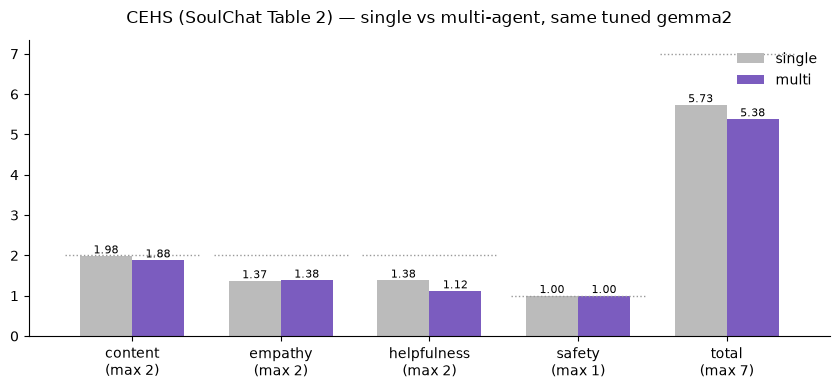

In [ ]:
# Chart: CEHS dimension means, single vs multi
COLORS = {"pipeline_single": "#BBBBBB", "pipeline_multi": "#7B5CBF"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

dims = list(svm.CEHS_DIMENSIONS) + ["total"]
x = np.arange(len(dims))
width = 0.35
plt.figure(figsize=(8.5, 4))
for k, system in enumerate(svm.SYSTEMS):
    vals = [float(scores[scores["system"] == system][d].iloc[0]) for d in dims]
    bars = plt.bar(x + (k - 0.5) * width, vals, width,
                   color=COLORS[system], label=system.replace("pipeline_", ""))
    plt.bar_label(bars, fmt="{:.2f}", fontsize=8)
maxes = [2, 2, 2, 1, 7]
for xi, m in zip(x, maxes):
    plt.hlines(m, xi - 0.45, xi + 0.45, colors="#999999",
               linestyles="dotted", linewidth=1)
plt.xticks(x, [f"{d}\n(max {m})" for d, m in zip(dims, maxes)])
plt.title("CEHS (SoulChat Table 2) — single vs multi-agent, same tuned gemma2",
          pad=12)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "chart_single_vs_multi.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Write results/single_vs_multi/report.md
lines = ["# Single-agent vs Multi-agent — multi-turn CEHS evaluation", "",
         f"{len(cases)} counsel-chat conversations replayed teacher-forced "
         f"({len(multi)} client turns); both arms use the same tuned gemma2. "
         "Replies scored per turn on the SoulChat CEHS rubric (Table 2, "
         "arXiv:2311.00273) by "
         f"{llm_judge.JUDGE_MODEL}.", "",
         "## CEHS scores (means; content/empathy/helpfulness 0-2, safety 0-1, "
         "total 0-7)", "",
         scores.to_markdown(index=False), "",
         "## Pipeline behavior (multi only)", "",
         f"- escalated turns: {n_esc}/{len(multi)} — these received the app's "
         "fixed crisis message",
         "- memory: the multi chatbot saw ONLY the summarizer's compression "
         "of the prior turns; the single agent saw the verbatim history", "",
         "## Diagnosed emotions across turns", ""]
lines += [f"- {emo}: {count}" for emo, count in emotions.items()]
lines += ["", "## Notes", "",
          "- Teacher-forced replay: at every client turn both systems answer "
          "the dataset's own context, so scores are paired per turn.",
          "- Prompts, thresholds, crisis message/regex, and the summarizer "
          "identity come from the app itself (evaluate/single_vs_multi.py).",
          "- The trimmed composed prompt has no {diagnostic_label} "
          "placeholder, so diagnosis affects the multi arm via crisis "
          "routing only."]
(OUT_DIR / "report.md").write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {OUT_DIR / 'report.md'}")


Wrote C:\Users\laoli\OneDrive\Desktop\MultiAgent2\fine_tuning_chatbot\results\single_vs_multi\report.md
